<a href="https://colab.research.google.com/github/sidyangel/WEATHER-DATA-ANALYZER/blob/main/WEATHER_DATA_ANALYZER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
import os
os.getcwd()
from  google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
os.chdir(r'/content/drive/MyDrive/')

In [4]:
df = pd.read_csv("weather_data_sample.csv")

In [5]:
df

,Date,Temperature_C,Humidity_Percent,Rainfall_mm,Wind_Speed_kmh,Pressure_hPa
0,2025-01-01,27.6,76.4,4.9,7.1,1015.2
1,2025-01-02,23.8,76.5,0.0,4.8,1011.4
2,2025-01-03,28.0,76.0,13.7,7.8,1011.9
3,2025-01-04,24.7,77.9,0.0,9.8,1015.4
4,2025-01-05,29.3,76.5,0.0,9.3,1016.3
...,...,...,...,...,...,...
360,2025-12-27,28.7,71.8,0.0,9.7,1012.8
361,2025-12-28,26.1,74.2,0.0,7.8,1015.6
362,2025-12-29,26.8,75.3,0.0,6.8,1014.1
363,2025-12-30,27.4,71.8,0.0,13.7,1011.9


# ***PART A***

### **Task 1**

1. How many observations and variables are in the dataset

In [6]:
df.shape

(365, 6)

2.What does each column represent?

In [7]:
df.columns

Index(['Date', 'Temperature_C', 'Humidity_Percent', 'Rainfall_mm',
       'Wind_Speed_kmh', 'Pressure_hPa'],
      dtype='object')

3. What are the data types of the columns?

In [8]:
df.dtypes

,0
Date,object
Temperature_C,float64
Humidity_Percent,float64
Rainfall_mm,float64
Wind_Speed_kmh,float64
Pressure_hPa,float64


4. Are there any missing values?

In [9]:
df.isnull().sum()

,0
Date,0
Temperature_C,0
Humidity_Percent,0
Rainfall_mm,0
Wind_Speed_kmh,0
Pressure_hPa,0


5. Display descriptive statistics for the numerical columns.

In [10]:
df.describe()

,Temperature_C,Humidity_Percent,Rainfall_mm,Wind_Speed_kmh,Pressure_hPa
count,365.000000,365.000000,365.000000,365.000000,365.000000
mean,28.143014,71.780548,4.326575,8.046027,1011.792055
std,2.667414,6.314829,6.892206,2.443969,3.350146
min,21.300000,55.400000,0.000000,1.000000,1002.200000
25%,26.200000,67.500000,0.000000,6.400000,1009.300000
50%,28.100000,71.500000,0.000000,8.000000,1011.900000
75%,30.100000,76.000000,6.900000,9.600000,1014.400000
max,34.900000,90.800000,39.800000,14.900000,1019.500000


### ***Task 2***

1.The temperature range.

In [11]:
temp_range = df['Temperature_C'].max() - df['Temperature_C'].min()
temp_range

13.599999999999998

2. The humidity range

In [12]:
humid_range = df['Humidity_Percent'].max() - df['Humidity_Percent'].min()
humid_range

35.4

3.The total rainfall during the year.

In [13]:
df['Rainfall_mm'].sum()

np.float64(1579.2)

4.The average wind speed.

In [14]:
df['Wind_Speed_kmh'].mean()

np.float64(8.046027397260275)

5.The average atmospheric pressure.

In [15]:
df['Pressure_hPa'].mean()

np.float64(1011.7920547945205)

# ***PART B***

### **Task 3**

1.

In [16]:
avg_temp = df['Temperature_C'].mean()
print("The Average Temperature of the year is", avg_temp)

The Average Temperature of the year is 28.14301369863014


2.

In [17]:
max_temp = df['Temperature_C'].max()
print("The highest temperature of the year is", max_temp)

The highest temperature of the year is 34.9


3.

In [18]:
min_temp = df['Temperature_C'].min()
print("The lowest temperature of the year is", min_temp)

The lowest temperature of the year is 21.3


4.

In [19]:
df[df['Temperature_C'] == df['Temperature_C'].max()]

,Date,Temperature_C,Humidity_Percent,Rainfall_mm,Wind_Speed_kmh,Pressure_hPa
175,2025-06-25,34.9,64.4,14.5,9.9,1007.3


In [20]:
df[df['Temperature_C'] == df['Temperature_C'].min()]

,Date,Temperature_C,Humidity_Percent,Rainfall_mm,Wind_Speed_kmh,Pressure_hPa
354,2025-12-21,21.3,76.4,0.0,8.7,1014.6
355,2025-12-22,21.3,67.6,0.0,8.8,1014.8


5.

In [21]:
yearly_avg_temp = df['Temperature_C'].mean()
days_above_avg = (df['Temperature_C'] > yearly_avg_temp).sum()

print(f"Yearly Average Temperature: {yearly_avg_temp:.2f}")
print(f"Number of days above average: {days_above_avg} days")

Yearly Average Temperature: 28.14
Number of days above average: 180 days


In [22]:
df[df['Temperature_C'] > df['Temperature_C'].mean()].shape[0]

180

Optional NumPy Challenge

# ***PART C***

### **Task 4**

1. What was the total rainfall for the year?  

In [23]:
df['Rainfall_mm'].sum()

np.float64(1579.2)

2. How many days recorded rainfall?  

In [24]:
days_recorded_rainfall = (df['Rainfall_mm'] > 0).sum()

print(f"Number of days recorded rainfall: {days_recorded_rainfall} days")

Number of days recorded rainfall: 156 days


3. Which day recorded the highest amount of rainfall?  

In [25]:
highest_rainfall = df['Rainfall_mm'].max()
highest_rainfall_date = df.loc[df['Rainfall_mm'].idxmax(), 'Date']
print(f"The highest wind speed was {highest_rainfall} on {highest_rainfall_date}")

The highest wind speed was 39.8 on 2025-08-20


4.

In [26]:
df['Date'] = pd.to_datetime(df['Date'])

rainy_days = df[df['Rainfall_mm'] > 0]
average_rainy_day_fall = rainy_days['Rainfall_mm'].mean()

print(f"4. The average rainfall on rainy days was: {average_rainy_day_fall:.2f} mm")


4. The average rainfall on rainy days was: 10.12 mm


5.

In [27]:
monthly_totals = df.groupby(df['Date'].dt.strftime('%B'))['Rainfall_mm'].sum()
highest_month = monthly_totals.idxmax()
highest_month_value = monthly_totals.max()

print(f"5. The month with the highest total rainfall was: {highest_month} ({highest_month_value:.2f} mm)")

5. The month with the highest total rainfall was: August (251.50 mm)


challenge

In [28]:
df['Rainy_Day'] = df['Rainfall_mm'].apply(
lambda score: "True" if score > 0
else "False"
)
df[['Date', 'Rainfall_mm', 'Rainy_Day']].head(20)

,Date,Rainfall_mm,Rainy_Day
0,2025-01-01,4.9,True
1,2025-01-02,0.0,False
2,2025-01-03,13.7,True
3,2025-01-04,0.0,False
4,2025-01-05,0.0,False
5,2025-01-06,0.0,False
6,2025-01-07,0.0,False
7,2025-01-08,0.0,False
8,2025-01-09,0.0,False
9,2025-01-10,4.3,True


# ***PART D***

### **Task 5**

1.

In [29]:
df['Humidity_Percent'].mean()

np.float64(71.78054794520547)

2.

In [30]:
max_humid = df['Humidity_Percent'].max()
min_humid = df['Humidity_Percent'].min()
print("The highest humidity is", max_humid)
print("The lowest humidity is", min_humid)

The highest humidity is 90.8
The lowest humidity is 55.4


3.

In [31]:
df['Rainy_Day'] = df['Rainfall_mm'] > 0

avg_hum_rainy = df[df['Rainy_Day'] == True]['Humidity_Percent'].mean()
avg_hum_dry = df[df['Rainy_Day'] == False]['Humidity_Percent'].mean()

print(f"3. Avg Humidity on Rainy Days: {avg_hum_rainy:.2f}%")
print(f"   Avg Humidity on Non-Rainy Days: {avg_hum_dry:.2f}%")
print(f"   Answer: {'Yes' if avg_hum_rainy > avg_hum_dry else 'No'}, humidity is higher on rainy days.")

3. Avg Humidity on Rainy Days: 71.58%
   Avg Humidity on Non-Rainy Days: 71.93%
   Answer: No, humidity is higher on rainy days.


### **Task 6**

In [32]:
df['Wind_Speed_kmh'].mean()

np.float64(8.046027397260275)

In [33]:
highest_wind_speed = df['Wind_Speed_kmh'].max()
highest_wind_speed_date = df.loc[df['Wind_Speed_kmh'].idxmax(), 'Date']
print(f"The highest wind speed was {highest_wind_speed} on {highest_wind_speed_date}")

The highest wind speed was 14.9 on 2025-07-20 00:00:00


In [34]:
df['Month_Name'] = df['Date'].dt.month_name()
monthly_wind = df.groupby('Month_Name')['Wind_Speed_kmh'].mean().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December']
)
print("\n3. Average Wind Speed by Month:")
print(monthly_wind.round(2))


3. Average Wind Speed by Month:
Month_Name
January      8.07
February     8.66
March        8.00
April        8.05
May          7.34
June         7.75
July         8.62
August       8.45
September    8.79
October      8.10
November     7.86
December     6.92
Name: Wind_Speed_kmh, dtype: float64


# ***PART E***

In [35]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month_Name"] = df["Date"].dt.month_name()
df["Month"] = df["Date"].dt.month
df.head()

,Date,Temperature_C,Humidity_Percent,Rainfall_mm,Wind_Speed_kmh,Pressure_hPa,Rainy_Day,Month_Name,Month
0,2025-01-01,27.6,76.4,4.9,7.1,1015.2,True,January,1
1,2025-01-02,23.8,76.5,0.0,4.8,1011.4,False,January,1
2,2025-01-03,28.0,76.0,13.7,7.8,1011.9,True,January,1
3,2025-01-04,24.7,77.9,0.0,9.8,1015.4,False,January,1
4,2025-01-05,29.3,76.5,0.0,9.3,1016.3,False,January,1


### **Task 7**

In [36]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Name'] = df['Date'].dt.month_name()

In [37]:
monthly_avg_wind = df.groupby('Month_Name')['Wind_Speed_kmh'].mean()

In [38]:
monthly_avg_temp = df.groupby('Month_Name')['Temperature_C'].mean()
monthly_avg_humidity = df.groupby('Month_Name')['Humidity_Percent'].mean()
monthly_total_rainfall = df.groupby('Month_Name')['Rainfall_mm'].sum()
monthly_avg_wind = df.groupby('Month_Name')['Wind_Speed_kmh'].mean()
print("=== Task 7: Monthly Weather Analysis Calculations ===")
for month in df['Month_Name'].unique():
    print(f"\n[{month}]")
    print(f"  1. Avg Temperature: {monthly_avg_temp[month]:.2f}°C")
    print(f"  2. Avg Humidity:    {monthly_avg_humidity[month]:.2f}%")
    print(f"  3. Total Rainfall:  {monthly_total_rainfall[month]:.2f} mm")
    print(f"  4. Avg Wind Speed:  {monthly_avg_wind[month]:.2f} km/h")

hottest_month = monthly_avg_temp.idxmax()
coolest_month = monthly_avg_temp.idxmin()
wettest_month = monthly_total_rainfall.idxmax()
most_humid_month = monthly_avg_humidity.idxmax()
print("\n=== Final Summary Answers ===")
print(f"• Which month was the hottest?    {hottest_month} ({monthly_avg_temp[hottest_month]:.2f}°C)")
print(f"• Which month was the coolest?    {coolest_month} ({monthly_avg_temp[coolest_month]:.2f}°C)")
print(f"• Which month was the wettest?    {wettest_month} ({monthly_total_rainfall[wettest_month]:.2f} mm)")
print(f"• Which month was the most humid? {most_humid_month} ({monthly_avg_humidity[most_humid_month]:.2f}%)")

=== Task 7: Monthly Weather Analysis Calculations ===

[January]
  1. Avg Temperature: 26.86°C
  2. Avg Humidity:    72.67%
  3. Total Rainfall:  47.80 mm
  4. Avg Wind Speed:  8.07 km/h

[February]
  1. Avg Temperature: 28.31°C
  2. Avg Humidity:    72.18%
  3. Total Rainfall:  58.40 mm
  4. Avg Wind Speed:  8.66 km/h

[March]
  1. Avg Temperature: 28.99°C
  2. Avg Humidity:    71.86%
  3. Total Rainfall:  105.70 mm
  4. Avg Wind Speed:  8.00 km/h

[April]
  1. Avg Temperature: 30.50°C
  2. Avg Humidity:    71.48%
  3. Total Rainfall:  135.50 mm
  4. Avg Wind Speed:  8.05 km/h

[May]
  1. Avg Temperature: 30.86°C
  2. Avg Humidity:    70.21%
  3. Total Rainfall:  162.80 mm
  4. Avg Wind Speed:  7.34 km/h

[June]
  1. Avg Temperature: 31.12°C
  2. Avg Humidity:    68.22%
  3. Total Rainfall:  234.40 mm
  4. Avg Wind Speed:  7.75 km/h

[July]
  1. Avg Temperature: 29.72°C
  2. Avg Humidity:    69.95%
  3. Total Rainfall:  166.70 mm
  4. Avg Wind Speed:  8.62 km/h

[August]
  1. Avg Temp

# ***PART F***

### **task 8**

In [39]:
df['Humidity_Percent'].min()

55.4

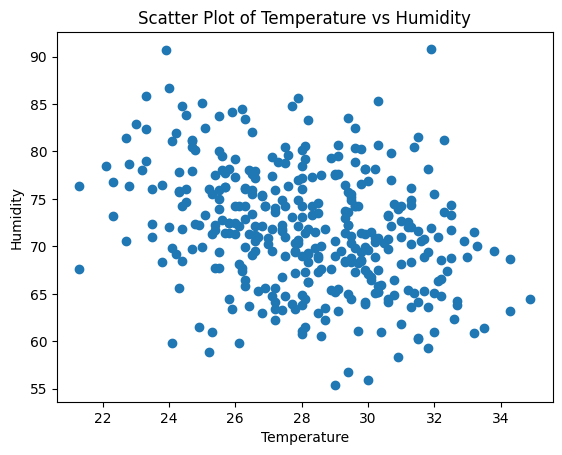

In [40]:
# relationship between temperature and humidity
plt.scatter(df['Temperature_C'], df['Humidity_Percent'])
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.title('Scatter Plot of Temperature vs Humidity')
plt.show()

**1. Relationship between Temperature and Humidity**: Yes, there is a clear negative correlation. As temperatures increase, the relative humidity tends to drop.

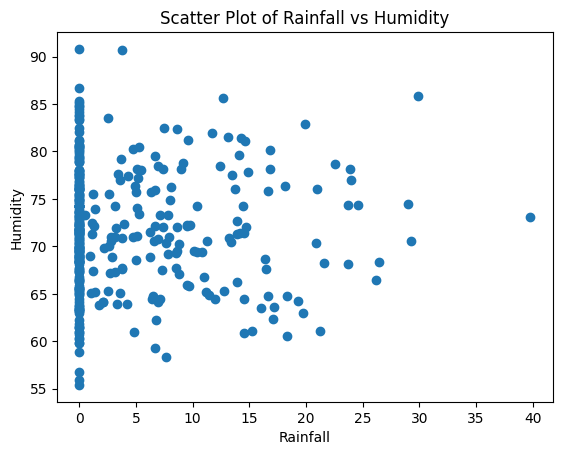

In [41]:
# relationship between rainfall and humidity
plt.scatter(df['Rainfall_mm'], df['Humidity_Percent'])
plt.xlabel('Rainfall')
plt.ylabel('Humidity')
plt.title('Scatter Plot of Rainfall vs Humidity')
df.corr(numeric_only=True)
plt.show()

**2. Rainfall and Humidity Relationship**: Yes, they have a positive relationship. On rainy days, the humidity stays very high. The dots cluster at the top of the plot shows that rainy days always have full atmospheric moisture.

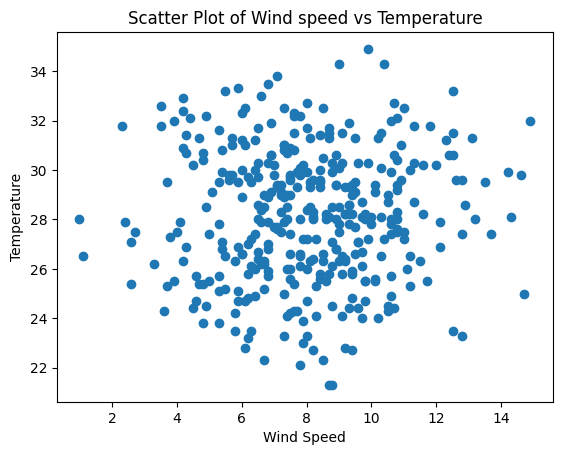

In [42]:
# relationship between rainfall and humidity
plt.scatter(df['Wind_Speed_kmh'], df['Temperature_C'])
plt.xlabel('Wind Speed')
plt.ylabel('Temperature')
plt.title('Scatter Plot of Wind speed vs Temperature')
df.corr(numeric_only=True)
plt.show()

**2. Rainfall and Humidity Relationship**: Yes, they have a positive relationship. On rainy days, the humidity stays very high. The dots cluster at the top of the plot. This shows that rainy days always have full atmospheric moisture.

# ***PART G***

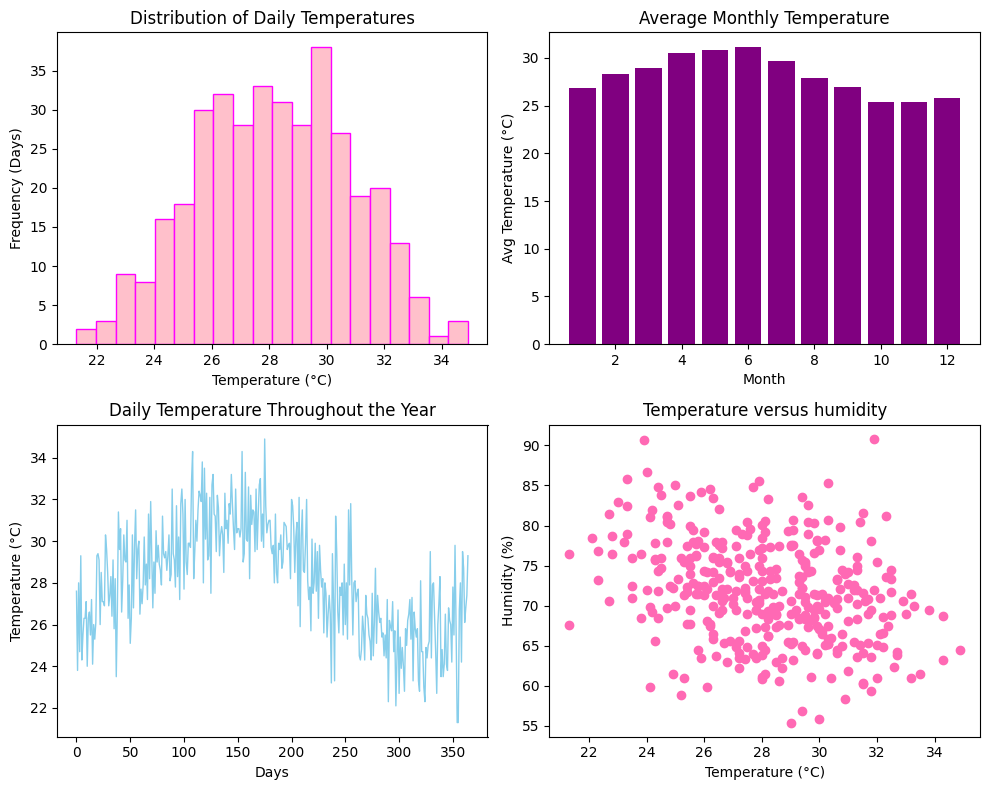

In [43]:
fig, axes = plt.subplots(2,2, figsize = (10,8))


axes[0, 0].hist(df['Temperature_C'], bins=20, color='pink', edgecolor='magenta')
axes[0, 0].set_title('Distribution of Daily Temperatures')
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Frequency (Days)')

monthly_temp = df.groupby('Month')['Temperature_C'].mean()
axes[0, 1].bar(monthly_temp.index, monthly_temp.values, color='purple')
axes[0, 1].set_title('Average Monthly Temperature')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Avg Temperature (°C)')

axes[1,0].plot(df.index, df['Temperature_C'], color='skyblue', linewidth=1)
axes[1,0].set_title('Daily Temperature Throughout the Year')
axes[1,0].set_xlabel('Days')
axes[1,0].set_ylabel('Temperature (°C)')

temperature = df['Temperature_C']
humidity = df['Humidity_Percent']
axes[1,1].scatter(temperature, humidity, color='hotpink')
axes[1,1].set_title('Temperature versus humidity')
axes[1,1].set_xlabel('Temperature (°C)')
axes[1,1].set_ylabel('Humidity (%)')

plt.tight_layout()

